# Customer Segmentation Project 
## Machine Learning II 

A K M SAIF HOQUE(20241418)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')

In [ ]:
customer_info=pd.read_csv("../data/customer_info.csv")
customer_basket=pd.read_csv("../data/customer_basket.csv")

# EDA

In [ ]:
customer_info.shape

(33038, 25)

In [ ]:
customer_basket.shape

(100000, 3)

In [ ]:
customer_info.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [ ]:
customer_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [ ]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [ ]:
customer_info.describe()

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


In [ ]:
customer_info.isnull().sum().sort_values(ascending=False)

loyalty_card_number                        13106
lifetime_spend_fish                          991
lifetime_spend_videogames                    661
typical_hour                                 661
lifetime_spend_meat                          661
lifetime_spend_electronics                   661
lifetime_spend_vegetables                    661
lifetime_spend_petfood                       661
number_complaints                            661
lifetime_spend_alcohol_drinks                330
lifetime_spend_hygiene                       330
percentage_of_products_bought_promotion      330
teens_home                                   330
kids_home                                    330
distinct_stores_visited                      330
customer_birthdate                           165
customer_id                                    0
lifetime_spend_groceries                       0
customer_name                                  0
customer_gender                                0
lifetime_spend_nonal

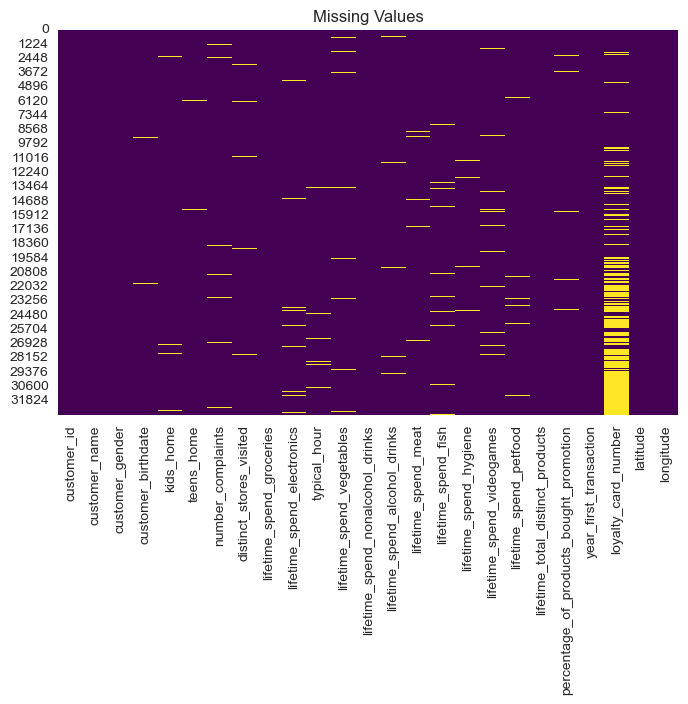

In [176]:
plt.figure(figsize=(8,5))
sns.heatmap(customer_info.isnull(), cbar=False,cmap='viridis')
plt.title("Missing Values")
plt.show()

In [ ]:
customer_info.duplicated().sum()

np.int64(0)

# DATA QUALITY CHECK

In [ ]:
customer_info[ customer_info["year_first_transaction"] > 2025][["customer_id", "year_first_transaction"]]

,customer_id,year_first_transaction
17,25,2029.0
28,37,2028.0
61,77,2026.0
66,82,2029.0
92,115,2027.0
...,...,...
32934,39878,2026.0
32937,39881,2029.0
32967,39914,2029.0
32971,39918,2026.0


In [ ]:
customer_info[(customer_info["percentage_of_products_bought_promotion"] < 0) |
    (customer_info["percentage_of_products_bought_promotion"] > 1)][["customer_id", "percentage_of_products_bought_promotion"]]

,customer_id,percentage_of_products_bought_promotion
8,12,-0.131176
26,35,-0.025524
28,37,-0.184820
65,81,-0.217805
71,87,-0.022180
...,...,...
32901,39840,-0.231363
32937,39881,-0.318683
32963,39909,-0.615508
32976,39924,-0.026162


In [ ]:
customer_info["customer_gender"].value_counts(dropna=False)

customer_gender
female    16577
male      16461
Name: count, dtype: int64

In [ ]:
customer_info["customer_birthdate"] = pd.to_datetime(customer_info["customer_birthdate"])

customer_info["customer_birthdate"].describe()

C:\Users\A K M NAZMUL HOQUE\AppData\Local\Temp\ipykernel_21160\3352576610.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_info["customer_birthdate"] = pd.to_datetime(customer_info["customer_birthdate"])


count                            32873
mean     1971-05-20 20:35:28.913089768
min                1940-01-02 06:03:00
25%                1955-09-04 09:16:00
50%                1971-07-05 14:59:00
75%                1987-03-30 14:07:00
max                2002-01-01 07:25:00
Name: customer_birthdate, dtype: object

In [ ]:
customer_info["typical_hour"].describe()

count    32377.000000
mean        12.659388
std          4.854708
min          6.000000
25%          8.000000
50%         12.000000
75%         16.000000
max         23.000000
Name: typical_hour, dtype: float64

In [ ]:
customer_info["number_complaints"].value_counts().sort_index()

number_complaints
0.0    10978
1.0    14760
2.0     5271
3.0      914
4.0      235
5.0      167
6.0       45
7.0        7
Name: count, dtype: int64

In [ ]:
spend_cols = [ "lifetime_spend_groceries", "lifetime_spend_electronics", "lifetime_spend_vegetables", "lifetime_spend_nonalcohol_drinks",
 "lifetime_spend_alcohol_drinks","lifetime_spend_meat","lifetime_spend_fish","lifetime_spend_hygiene","lifetime_spend_videogames",
    "lifetime_spend_petfood"]
(customer_info[spend_cols] < 0).sum()

lifetime_spend_groceries            0
lifetime_spend_electronics          0
lifetime_spend_vegetables           0
lifetime_spend_nonalcohol_drinks    0
lifetime_spend_alcohol_drinks       0
lifetime_spend_meat                 0
lifetime_spend_fish                 0
lifetime_spend_hygiene              0
lifetime_spend_videogames           0
lifetime_spend_petfood              0
dtype: int64

## DATA CLEANING & FILLING MISSING VALUE

In [ ]:
customer_clean = customer_info.copy()

In [ ]:
customer_clean["percentage_of_products_bought_promotion"] = (customer_clean["percentage_of_products_bought_promotion"].clip(0, 1))

In [ ]:
customer_clean["has_loyalty_card"] = (customer_clean["loyalty_card_number"].notna().astype(int))
customer_clean.drop(columns=['loyalty_card_number'],inplace=True)

In [ ]:
numeric_cols = customer_clean.select_dtypes( include=["int64", "float64"]).columns

customer_clean[numeric_cols] = customer_clean[numeric_cols].fillna(customer_clean[numeric_cols].median())

In [ ]:
customer_clean["customer_birthdate"] = pd.to_datetime( customer_clean["customer_birthdate"],)

In [ ]:
median_birthdate = customer_clean["customer_birthdate"].median()

customer_clean["customer_birthdate"] = (customer_clean["customer_birthdate"].fillna(median_birthdate))

In [ ]:
customer_clean.isnull().sum().sort_values(ascending=False)

customer_id                                0
customer_name                              0
customer_gender                            0
customer_birthdate                         0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
latitude  

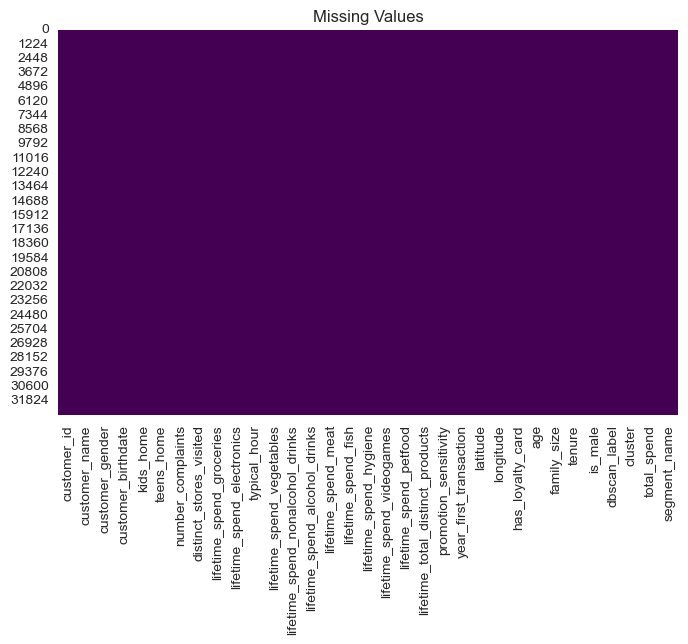

In [177]:
plt.figure(figsize=(8,5))
sns.heatmap(customer_clean.isnull(), cbar=False,cmap="viridis")
plt.title("Missing Values")
plt.show()

## FEATURE ENGINEERING

In [ ]:
REFERENCE_YEAR = 2026

In [ ]:
customer_clean["age"] = (REFERENCE_YEAR -customer_clean["customer_birthdate"].dt.year)


In [ ]:
customer_clean["family_size"] = (customer_clean["kids_home"] +customer_clean["teens_home"] +1)


In [ ]:
customer_clean["tenure"] = (REFERENCE_YEAR -customer_clean["year_first_transaction"])

customer_clean["tenure"] = customer_clean["tenure"].clip(lower=0) # I am making sure that future years are not creating negative tenure values and becmoes 0 instead


In [ ]:
customer_clean.rename(columns={"percentage_of_products_bought_promotion":"promotion_sensitivity"},inplace=True)


In [ ]:
customer_clean[ ["age","family_size","tenure","promotion_sensitivity","has_loyalty_card"]].describe()

,age,family_size,tenure,promotion_sensitivity,has_loyalty_card
count,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000
mean,55.119650,3.014862,10.748683,0.324560,0.603305
std,18.019387,1.771471,4.886917,0.271470,0.489219
min,24.000000,1.000000,0.000000,0.000000,0.000000
25%,39.000000,2.000000,7.000000,0.123383,0.000000
50%,55.000000,3.000000,11.000000,0.239449,1.000000
75%,71.000000,3.000000,14.000000,0.465200,1.000000
max,86.000000,15.000000,33.000000,1.000000,1.000000


In [ ]:
customer_clean["is_male"] = (customer_clean["customer_gender"] == "male").astype(int)

In [ ]:
customer_clean['is_male'].value_counts()

is_male
0    16577
1    16461
Name: count, dtype: int64

## CLUSTERING DATASET

In [ ]:
cluster_features = [
    # Demographics
    "age","family_size","tenure","is_male",
    # Behaviour
    "number_complaints","distinct_stores_visited","lifetime_total_distinct_products","typical_hour","promotion_sensitivity",
     # Loyalty
    "has_loyalty_card",
    # Spending Categories
    "lifetime_spend_groceries","lifetime_spend_electronics","lifetime_spend_vegetables","lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks","lifetime_spend_meat","lifetime_spend_fish","lifetime_spend_hygiene","lifetime_spend_videogames","lifetime_spend_petfood"
]

X = customer_clean[cluster_features].copy()

print(f"Shape: {X.shape}")
X.head()

Shape: (33038, 20)


,age,family_size,tenure,is_male,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,typical_hour,promotion_sensitivity,has_loyalty_card,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
0,56,3.0,6.0,0,1.0,3.0,189.0,12.0,0.631599,1,11731.0,4553.0,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0
1,51,2.0,13.0,0,0.0,2.0,130.0,12.0,0.149890,1,13694.0,963.0,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0
2,55,1.0,21.0,1,1.0,2.0,81.0,11.0,0.069126,0,12407.0,0.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0
3,44,1.0,5.0,1,2.0,1.0,92.0,18.0,0.253609,1,7493.0,1105.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0
4,57,1.0,5.0,1,3.0,1.0,6.0,17.0,0.186569,1,9187.0,10841.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0


## SCALING FOR DBSCAN

In [ ]:
dbscan_scaler = StandardScaler()

X_dbscan = dbscan_scaler.fit_transform(X)

X_dbscan.shape

(33038, 20)

In [ ]:
dbscan = DBSCAN(
    eps=3,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_dbscan)

pd.Series(dbscan_labels).value_counts().head()

 0    31168
-1     1870
Name: count, dtype: int64

In [ ]:
noise_count = (dbscan_labels == -1).sum()

print("Noise points:", noise_count)
print("Percentage:",
      round(noise_count / len(dbscan_labels) * 100, 2),
      "%")

Noise points: 1870
Percentage: 5.66 %


In [ ]:
customer_clean['dbscan_label'] = dbscan_labels

In [ ]:
outlier_summary = customer_clean.groupby('dbscan_label')[cluster_features].mean()

outlier_summary.T

dbscan_label,-1,0
age,55.526203,55.095258
family_size,4.930481,2.899929
tenure,10.981283,10.734728
is_male,0.501070,0.498075
number_complaints,1.398396,0.904261
distinct_stores_visited,3.376471,3.153651
lifetime_total_distinct_products,253.581818,142.634882
typical_hour,12.053476,12.681757
promotion_sensitivity,0.304080,0.325789
has_loyalty_card,0.498930,0.609568


In [ ]:
customer_clean[customer_clean['dbscan_label'] == -1][cluster_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1870.0,55.526203,18.763092,25.0,39.00000,56.000000,72.000000,86.0
family_size,1870.0,4.930481,3.209216,1.0,2.00000,4.000000,7.000000,15.0
tenure,1870.0,10.981283,6.372860,0.0,6.00000,11.000000,15.000000,33.0
is_male,1870.0,0.501070,0.500133,0.0,0.00000,1.000000,1.000000,1.0
number_complaints,1870.0,1.398396,1.462240,0.0,0.00000,1.000000,2.000000,7.0
distinct_stores_visited,1870.0,3.376471,1.962048,1.0,2.00000,3.000000,5.000000,10.0
lifetime_total_distinct_products,1870.0,253.581818,130.863513,0.0,154.25000,253.000000,345.000000,600.0
typical_hour,1870.0,12.053476,4.305275,6.0,9.00000,11.000000,14.000000,23.0
promotion_sensitivity,1870.0,0.304080,0.244285,0.0,0.14406,0.239449,0.381797,1.0
has_loyalty_card,1870.0,0.498930,0.500133,0.0,0.00000,0.000000,1.000000,1.0


In [ ]:
customer_clean[customer_clean['dbscan_label'] != -1][cluster_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,31168.0,55.095258,17.973808,24.0,39.000000,55.000000,71.000000,86.0
family_size,31168.0,2.899929,1.573341,1.0,2.000000,3.000000,3.000000,13.0
tenure,31168.0,10.734728,4.782881,0.0,7.000000,11.000000,14.000000,29.0
is_male,31168.0,0.498075,0.500004,0.0,0.000000,0.000000,1.000000,1.0
number_complaints,31168.0,0.904261,0.830374,0.0,0.000000,1.000000,1.000000,6.0
distinct_stores_visited,31168.0,3.153651,1.645531,1.0,2.000000,3.000000,4.000000,10.0
lifetime_total_distinct_products,31168.0,142.634882,100.842139,0.0,65.000000,118.000000,200.000000,600.0
typical_hour,31168.0,12.681757,4.832970,6.0,8.000000,12.000000,16.000000,23.0
promotion_sensitivity,31168.0,0.325789,0.272969,0.0,0.122302,0.239449,0.470257,1.0
has_loyalty_card,31168.0,0.609568,0.487855,0.0,0.000000,1.000000,1.000000,1.0


In [ ]:
customer_clean[customer_clean['dbscan_label'] == -1]
[["customer_id","age","family_size","number_complaints",
"distinct_stores_visited","promotion_sensitivity",
"lifetime_total_distinct_products"]].head(20)

,customer_id,age,family_size,number_complaints,distinct_stores_visited,promotion_sensitivity,lifetime_total_distinct_products
7,11,49,3.0,1.0,6.0,0.164251,180.0
28,37,26,3.0,0.0,5.0,0.000000,330.0
54,70,80,1.0,1.0,2.0,0.276803,193.0
71,87,49,3.0,1.0,3.0,0.000000,337.0
91,114,80,3.0,1.0,4.0,0.183979,208.0
93,116,78,1.0,5.0,1.0,0.308863,142.0
122,149,47,7.0,1.0,7.0,0.066680,221.0
126,158,53,1.0,0.0,6.0,0.171159,267.0
135,170,65,3.0,0.0,1.0,0.819469,7.0
172,215,80,2.0,0.0,2.0,0.954226,490.0


## DBSCAN Outlier Analysis

DBSCAN was applied using StandardScaler (`eps=3`, `min_samples=10`) to investigate potential outliers before clustering.

The algorithm identified 1,870 customers (5.66% of the dataset) as noise points. These observations were further analysed by comparing their characteristics with the remaining customers.

The analysis showed that the identified observations did not correspond to erroneous or unrealistic data. Instead, they represented customers with legitimate but distinct behaviours, including larger family sizes, higher spending levels, and a greater diversity of purchased products.

Since these customers constitute meaningful business profiles rather than data quality issues, all observations were retained for the subsequent clustering analysis.

## Data Scaling for Clustering

In [ ]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")

Shape: (33038, 20)


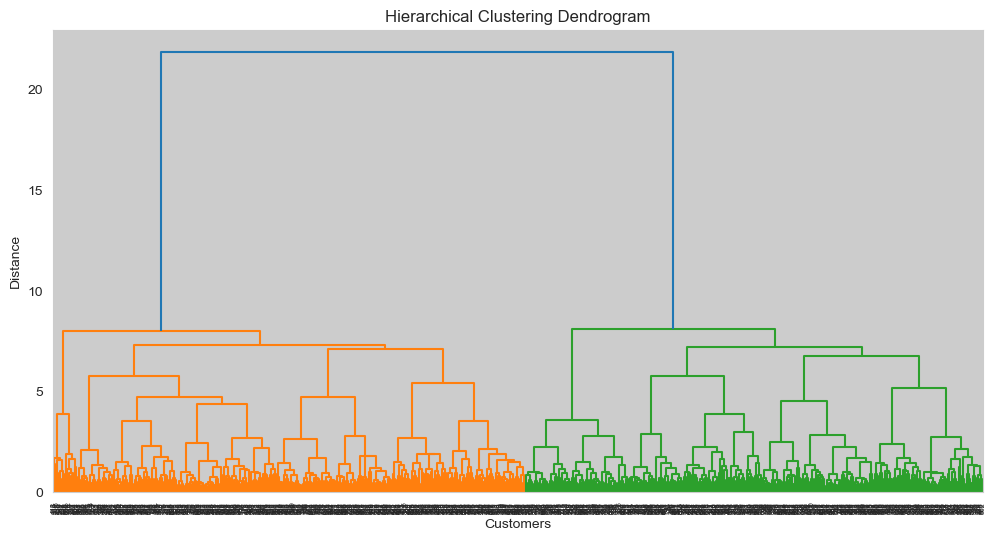

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(12, 6))

linked = linkage(
    X_scaled[:1000],   # i am using only the first 1000 samples to make the dendrogram more readable
    method='ward'
)

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

## Elbow Method for Selecting the Number of Clusters

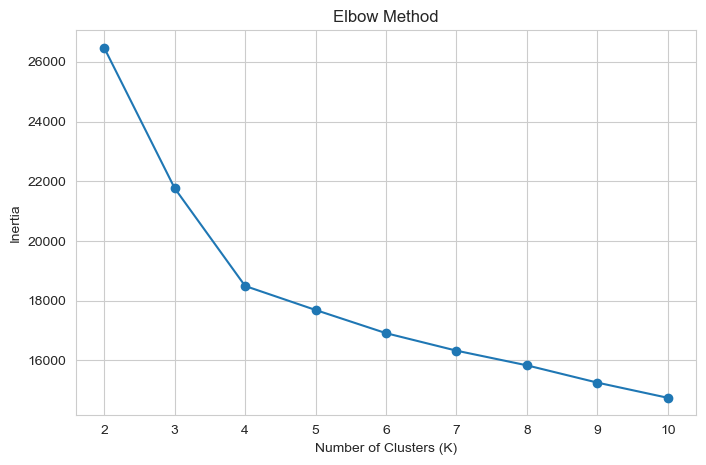

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K)
plt.show()

## Silhouette Analysis

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K={k}: {score:.4f}")

K=2: 0.2307
K=3: 0.2324
K=4: 0.2861
K=5: 0.2326
K=6: 0.1931
K=7: 0.1931
K=8: 0.1675
K=9: 0.1687
K=10: 0.1505


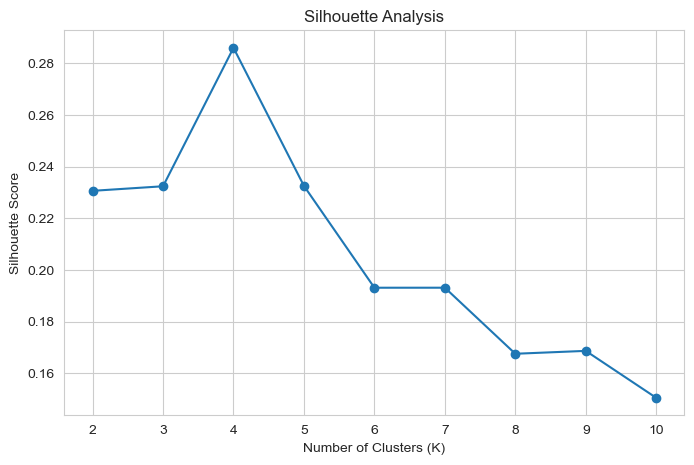

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.xticks(K)

plt.show()

## Final Number of Clusters

The number of clusters was determined using three approaches:

- Hierarchical clustering dendrogram
- Elbow method
- Silhouette analysis

The dendrogram suggested a range between 2 and 5 clusters.

The elbow method showed a clear bend at K = 4.

The silhouette analysis achieved its highest score at K = 4.

Therefore, K = 4 was selected as the final number of customer segments.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_clean['cluster'] = kmeans.fit_predict(X_scaled)

customer_clean['cluster'].value_counts().sort_index()

cluster
0    6475
1    9986
2    9946
3    6631
Name: count, dtype: int64

In [ ]:
cluster_profile = customer_clean.groupby('cluster')[cluster_features].mean().round(2)

cluster_profile

,age,family_size,tenure,is_male,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,typical_hour,promotion_sensitivity,has_loyalty_card,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
cluster,,,,,,,,,,,,,,,,,,,,
0,53.49,2.97,9.96,1.0,0.97,3.13,144.22,12.96,0.31,0.0,14871.47,2877.78,726.75,445.88,671.86,647.85,565.95,761.28,396.29,325.77
1,55.88,3.11,11.26,1.0,0.91,3.20,154.24,12.39,0.33,1.0,17440.31,2594.68,732.84,478.87,589.98,772.45,638.64,858.67,346.20,342.45
2,56.33,3.04,11.23,0.0,0.90,3.18,149.95,12.43,0.33,1.0,17082.16,2620.64,724.78,472.45,582.56,767.30,617.74,859.63,351.06,345.43
3,53.74,2.89,10.02,0.0,0.98,3.14,143.92,13.06,0.32,0.0,14835.51,2989.44,697.35,448.37,674.48,659.60,577.57,754.71,412.98,322.30


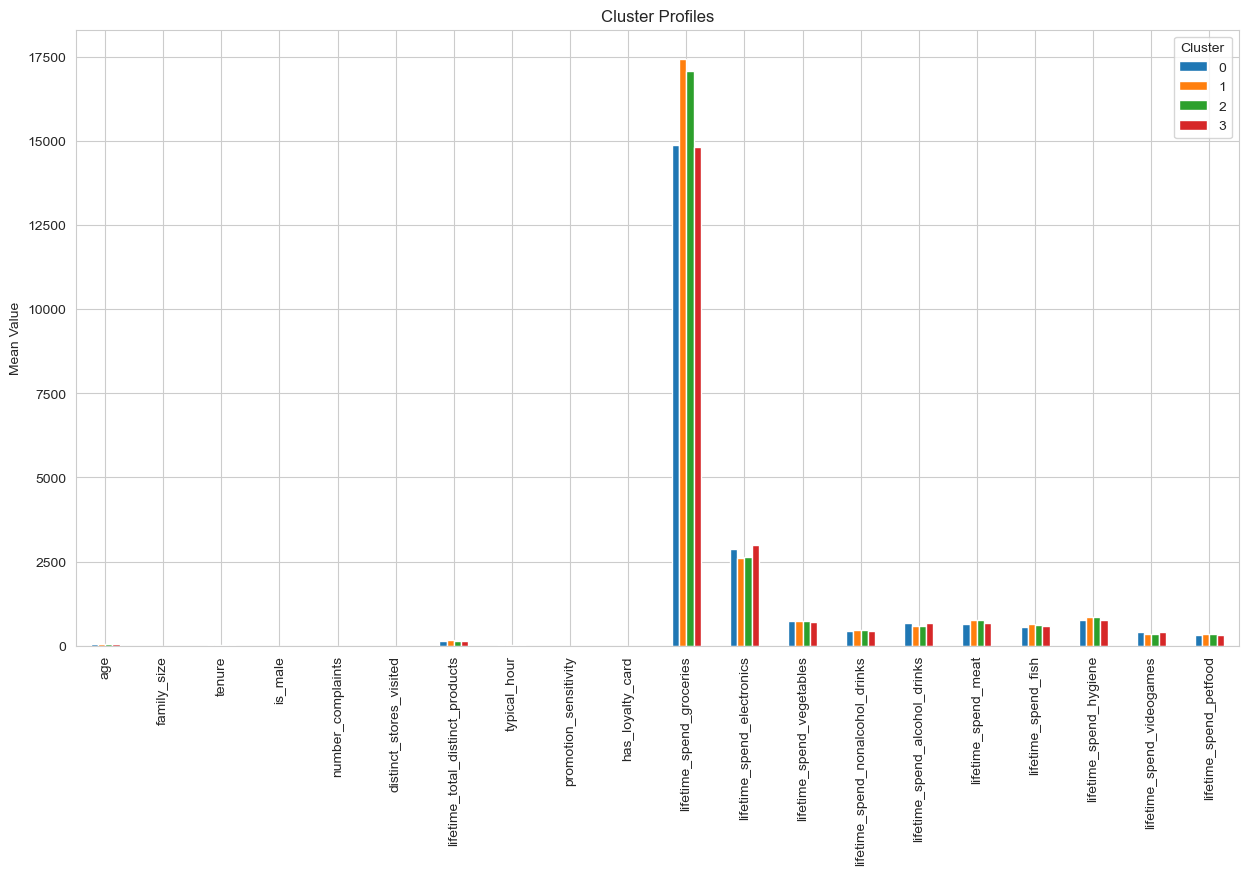

In [ ]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(15,8)
)

plt.title('Cluster Profiles')
plt.ylabel('Mean Value')
plt.legend(title='Cluster')

plt.show()

# PCA

In [ ]:
pca_features = [
    f for f in cluster_features
    if f not in ['is_male', 'has_loyalty_card']
]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_pca = StandardScaler()

X_pca_input = customer_clean[pca_features]

X_pca_scaled = scaler_pca.fit_transform(X_pca_input)

X_pca_scaled.shape

(33038, 18)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_pca_scaled)

X_pca.shape

(33038, 2)

In [ ]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:",
      round(pca.explained_variance_ratio_.sum() * 100, 2),
      "%")

Explained variance ratio:
[0.20621679 0.14478091]

Total explained variance: 35.1 %


In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = customer_clean['cluster']

pca_df.head()

,PC1,PC2,cluster
0,-1.281011,-0.662553,2
1,-2.012388,2.170539,2
2,-1.227358,-0.076457,0
3,1.207486,-3.197883,1
4,1.283833,-3.476492,1


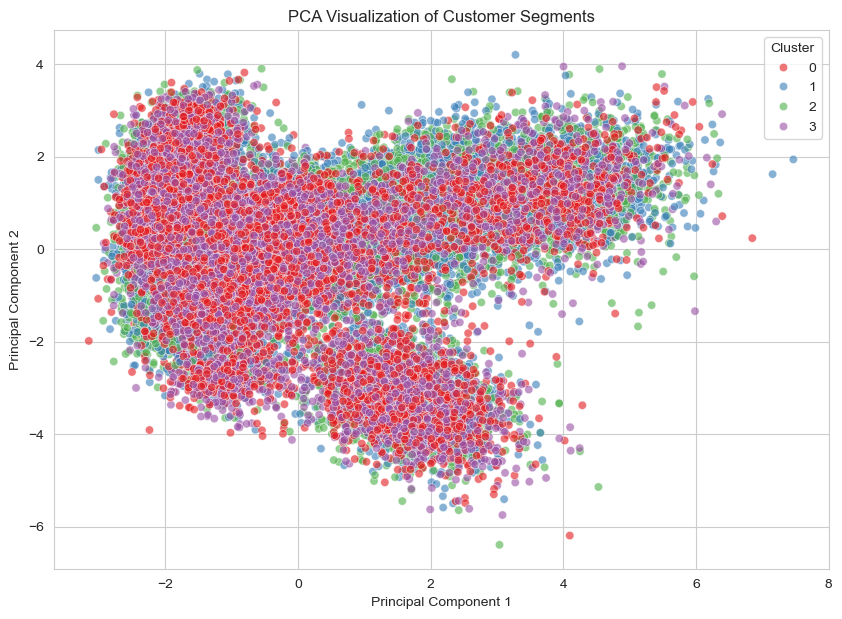

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    alpha=0.6
)

plt.title('PCA Visualization of Customer Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')

plt.show()

In [ ]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_features
)

print("Top variables for PC1:")
print(
    pca_loadings['PC1']
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop variables for PC2:")
print(
    pca_loadings['PC2']
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

Top variables for PC1:
lifetime_spend_fish                 0.407540
lifetime_spend_meat                 0.392216
lifetime_spend_alcohol_drinks       0.377087
lifetime_total_distinct_products    0.342589
lifetime_spend_nonalcohol_drinks    0.316286
lifetime_spend_electronics          0.298721
lifetime_spend_groceries            0.250531
family_size                         0.248445
lifetime_spend_videogames           0.209954
lifetime_spend_vegetables           0.186427
Name: PC1, dtype: float64

Top variables for PC2:
lifetime_spend_hygiene              0.424650
lifetime_spend_videogames           0.369382
lifetime_spend_vegetables           0.314540
typical_hour                        0.288236
lifetime_spend_electronics          0.276483
family_size                         0.259582
lifetime_total_distinct_products    0.239944
lifetime_spend_groceries            0.223333
tenure                              0.222497
lifetime_spend_nonalcohol_drinks    0.200380
Name: PC2, dtype: float64


#  Alternative Feature Set Evaluation

In [ ]:
customer_clean['total_spend'] = customer_clean[spend_cols].sum(axis=1)

In [ ]:
reduced_features = [
    'age',
    'family_size',
    'tenure',
    'is_male',
    'number_complaints',
    'distinct_stores_visited',
    'promotion_sensitivity',
    'has_loyalty_card',
    'lifetime_total_distinct_products',
    'total_spend'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

X_reduced = customer_clean[reduced_features]

scaler_reduced = StandardScaler()

X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

X_reduced_scaled.shape

(33038, 10)

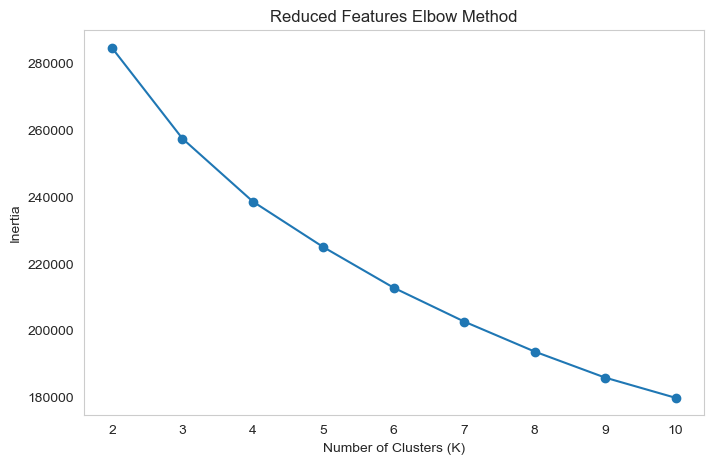

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_reduced = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_reduced_scaled)

    inertia_reduced.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia_reduced,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Reduced Features Elbow Method")

plt.grid()

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores_reduced = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_reduced_scaled)

    score = silhouette_score(
        X_reduced_scaled,
        labels
    )

    silhouette_scores_reduced.append(score)

    print(f"K={k}: {score:.4f}")

K=2: 0.1910
K=3: 0.1277
K=4: 0.1231
K=5: 0.1174
K=6: 0.1281
K=7: 0.1313
K=8: 0.1213
K=9: 0.1289
K=10: 0.1431


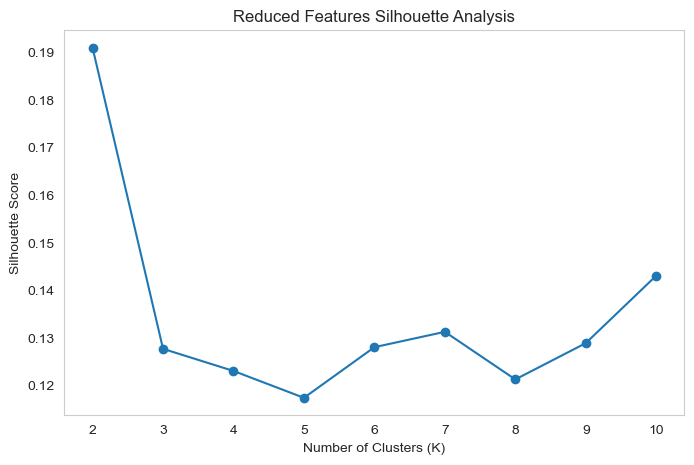

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores_reduced,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Reduced Features Silhouette Analysis")

plt.grid()

plt.show()

In [ ]:
comparison = pd.DataFrame({
    'K': range(2,11),
    'Current_Model': silhouette_scores,
    'Reduced_Model': silhouette_scores_reduced
})

comparison

,K,Current_Model,Reduced_Model
0,2,0.230663,0.191014
1,3,0.232431,0.127743
2,4,0.286065,0.123094
3,5,0.232577,0.117448
4,6,0.193128,0.128089
5,7,0.193136,0.131320
6,8,0.167546,0.121314
7,9,0.168666,0.128939
8,10,0.150481,0.143122


# K-Means Stability Analysis

In [ ]:
for n in [10, 20, 50, 100]:
    kmeans = KMeans(
        n_clusters=4,
        init='k-means++',
        n_init=n,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"n_init={n}: {score:.4f}")

n_init=10: 0.2861
n_init=20: 0.2861
n_init=50: 0.2861
n_init=100: 0.2861


# SEGMENTATION


In [ ]:
customer_clean['cluster'].value_counts().sort_index()

cluster
0    6475
1    9986
2    9946
3    6631
Name: count, dtype: int64

In [ ]:
cluster_profiles = customer_clean.groupby('cluster')[cluster_features].mean().round(2)

cluster_profiles

,age,family_size,tenure,is_male,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,typical_hour,promotion_sensitivity,has_loyalty_card,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
cluster,,,,,,,,,,,,,,,,,,,,
0,53.49,2.97,9.96,1.0,0.97,3.13,144.22,12.96,0.31,0.0,14871.47,2877.78,726.75,445.88,671.86,647.85,565.95,761.28,396.29,325.77
1,55.88,3.11,11.26,1.0,0.91,3.20,154.24,12.39,0.33,1.0,17440.31,2594.68,732.84,478.87,589.98,772.45,638.64,858.67,346.20,342.45
2,56.33,3.04,11.23,0.0,0.90,3.18,149.95,12.43,0.33,1.0,17082.16,2620.64,724.78,472.45,582.56,767.30,617.74,859.63,351.06,345.43
3,53.74,2.89,10.02,0.0,0.98,3.14,143.92,13.06,0.32,0.0,14835.51,2989.44,697.35,448.37,674.48,659.60,577.57,754.71,412.98,322.30


In [ ]:
cluster_medians = customer_clean.groupby('cluster')[cluster_features].median()

cluster_medians

,age,family_size,tenure,is_male,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,typical_hour,promotion_sensitivity,has_loyalty_card,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
cluster,,,,,,,,,,,,,,,,,,,,
0,53.0,3.0,10.0,1.0,1.0,3.0,118.0,12.0,0.234609,0.0,12028.0,1490.0,468.0,409.0,546.0,630.0,492.0,630.0,222.0,319.0
1,56.0,3.0,11.0,1.0,1.0,3.0,130.0,12.0,0.239461,1.0,13909.0,1470.0,476.5,435.5,448.0,779.0,511.5,724.0,223.0,331.0
2,56.0,3.0,11.0,0.0,1.0,3.0,124.0,12.0,0.239449,1.0,13667.5,1447.5,471.5,427.0,433.0,777.0,511.0,726.0,223.0,334.0
3,53.0,3.0,10.0,0.0,1.0,3.0,117.0,12.0,0.239449,0.0,12015.0,1497.0,442.0,411.0,553.0,642.0,511.0,619.0,223.0,317.0


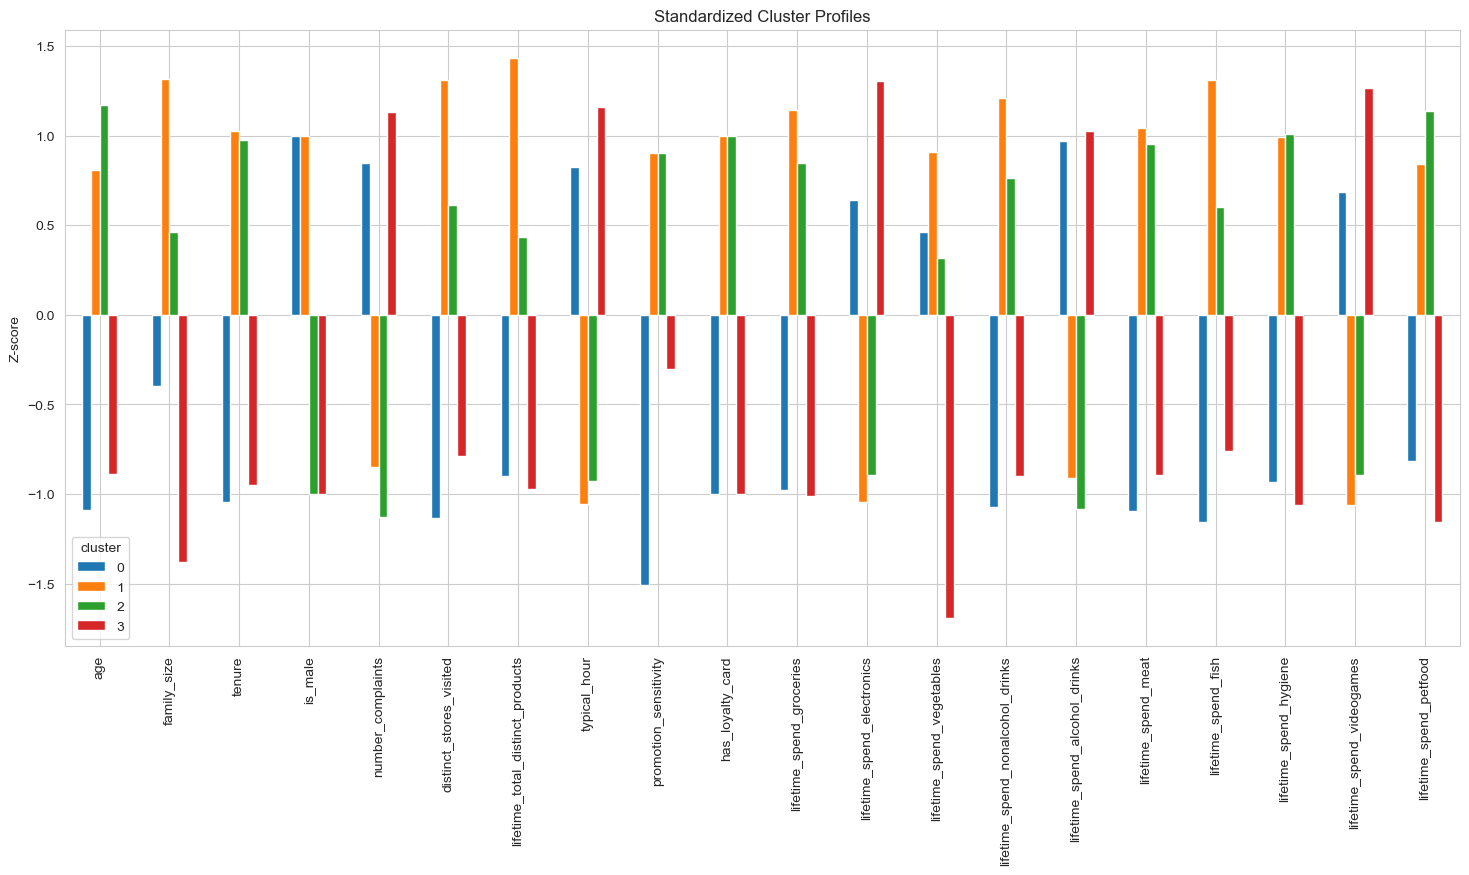

In [ ]:


profile_scaler = StandardScaler()

cluster_profiles_scaled = pd.DataFrame(
    profile_scaler.fit_transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

cluster_profiles_scaled.T.plot(
    kind='bar',
    figsize=(18,8)
)

plt.title('Standardized Cluster Profiles')
plt.ylabel('Z-score')

plt.show()

<Figure size 1400x600 with 0 Axes>

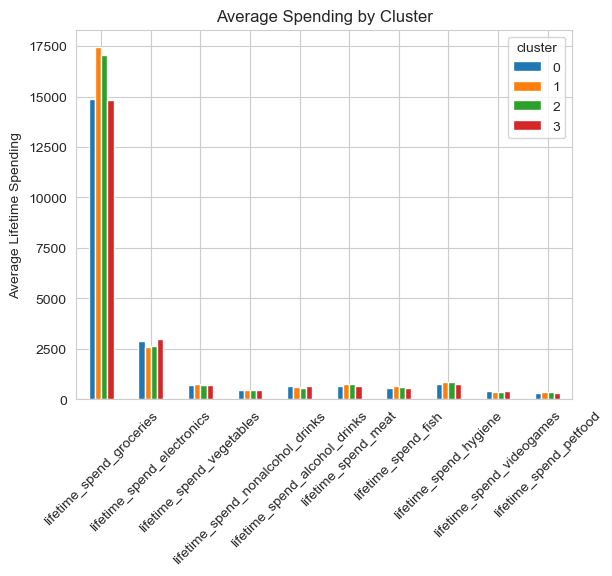

In [166]:

spending_cols = [
    'lifetime_spend_groceries',
    'lifetime_spend_electronics',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_videogames',
    'lifetime_spend_petfood'
]

cluster_spending = customer_clean.groupby('cluster')[spending_cols].mean()

plt.figure(figsize=(14,6))
cluster_spending.T.plot(kind='bar')
plt.title("Average Spending by Cluster")
plt.ylabel("Average Lifetime Spending")
plt.xticks(rotation=45)
plt.show()

In [180]:
segment_names = {
    0: 'Occasional Traditional Customers',
    1: 'Loyal High-Value Customers',
    2: 'Family-Oriented Customers',
    3: 'Specialized Customers'
}

customer_clean['segment_name'] = customer_clean['cluster'].map(segment_names)



customer_clean[
    ['cluster','segment_name']
].drop_duplicates().sort_values('cluster')

,cluster,segment_name
2,0,Occasional Traditional Customers
3,1,Loyal High-Value Customers
0,2,Family-Oriented Customers
8,3,Specialized Customers


In [157]:
segment_summary = pd.DataFrame({
    'Customers': customer_clean['cluster'].value_counts().sort_index(),
    'Percentage (%)': (
        customer_clean['cluster']
        .value_counts(normalize=True)
        .sort_index()*100
    ).round(2)
})

segment_summary

,Customers,Percentage (%)
cluster,,
0,6475,19.60
1,9986,30.23
2,9946,30.10
3,6631,20.07


In [158]:
customer_clean.to_csv("../outputs/customer_segments.csv", index=False)
segment_summary.to_csv("../outputs/segment_summary.csv", index=True)

# ASSOCIATION RULE

In [178]:
#!pip install mlxtend

In [ ]:
import ast

customer_basket['list_of_goods'] = customer_basket[
    'list_of_goods'
].apply(ast.literal_eval)

In [133]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [134]:
basket_sample = customer_basket.sample(
    n=30000,
    random_state=42
)

print("Sample size:", basket_sample.shape)

Sample size: (30000, 3)


In [135]:
transactions = basket_sample['list_of_goods'].tolist()

print("Number of transactions:", len(transactions))
print(transactions[:2])

Number of transactions: 30000
[['avocado', 'rice', 'shampoo', 'tomatoes', 'chocolate bread', 'butter', 'pasta', 'mayonnaise', 'almonds', 'shower gel', 'mineral water', 'toilet paper', 'french wine', 'cooking oil', 'milk'], ['antioxydant juice', 'megaman zero 2', 'chocolate', 'final fantasy XXII', 'minecraft']]


In [136]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("Original basket shape:", basket_encoded.shape)

Original basket shape: (30000, 164)


In [137]:
product_support = basket_encoded.mean()

selected_products = product_support[
    product_support >= 0.02
].index

basket_encoded = basket_encoded[selected_products]

print(basket_encoded.shape)

(30000, 164)


In [138]:
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.03,
    use_colnames=True,
    max_len=2
)

frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(20)

,support,itemsets
3,0.127967,(asparagus)
0,0.120667,(airpods)
26,0.100933,(cereals)
56,0.099600,(fresh bread)
18,0.096167,(butter)
45,0.093400,(eggs)
146,0.084867,(toilet paper)
120,0.084800,(protein bar)
36,0.083633,(cooking oil)
43,0.081400,(dog food)


In [141]:
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.01,
    use_colnames=True,
    max_len=2
)

print("Frequent itemsets:", frequent_itemsets.shape)

frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(20)

Frequent itemsets: (312, 2)


,support,itemsets
3,0.127967,(asparagus)
0,0.120667,(airpods)
26,0.100933,(cereals)
56,0.099600,(fresh bread)
18,0.096167,(butter)
45,0.093400,(eggs)
146,0.084867,(toilet paper)
120,0.084800,(protein bar)
36,0.083633,(cooking oil)
43,0.081400,(dog food)


In [154]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.20
)

print("Number of rules:", rules.shape[0])

rules.head()

Number of rules: 62


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(airpods),(bluetooth headphones),0.120667,0.074000,0.025567,0.211878,2.863222,1.0,0.016637,1.174946,0.740041,0.151193,0.148897,0.278687
1,(bluetooth headphones),(airpods),0.074000,0.120667,0.025567,0.345495,2.863222,1.0,0.016637,1.343510,0.702746,0.151193,0.255681,0.278687
2,(candy bars),(airpods),0.051533,0.120667,0.010467,0.203105,1.683189,1.0,0.004248,1.103449,0.427943,0.064716,0.093751,0.144923
3,(chocolate),(airpods),0.054067,0.120667,0.011067,0.204686,1.696289,1.0,0.004543,1.105642,0.433940,0.067617,0.095548,0.148199
4,(energy bar),(airpods),0.081233,0.120667,0.016767,0.206401,1.710508,1.0,0.006965,1.108033,0.452104,0.090565,0.097500,0.172676


In [155]:

rules_support = rules.sort_values(
    ['support', 'confidence'],
    ascending=False
)


top_promotions = rules_support[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(20)

top_promotions

,antecedents,consequents,support,confidence,lift
1,(bluetooth headphones),(airpods),0.025567,0.345495,2.863222
0,(airpods),(bluetooth headphones),0.025567,0.211878,2.863222
6,(energy drink),(airpods),0.024467,0.334244,2.769979
5,(airpods),(energy drink),0.024467,0.202762,2.769979
41,(fresh bread),(cereals),0.022633,0.227242,2.251410
42,(cereals),(fresh bread),0.022633,0.224240,2.251410
39,(eggs),(cereals),0.022033,0.235903,2.337215
40,(cereals),(eggs),0.022033,0.218296,2.337215
33,(butter),(cereals),0.021067,0.219064,2.170384
34,(cereals),(butter),0.021067,0.208719,2.170384


In [159]:
rules_support.to_csv("../outputs/association_rules.csv",index=False)
top_promotions.to_csv("../outputs/top_promotions.csv",index=False)

In [161]:
submission = customer_clean[["customer_id", "cluster"]]

submission.head()

,customer_id,cluster
0,3,2
1,4,2
2,5,0
3,7,1
4,8,1


In [163]:
submission.to_csv("../outputs/customer_clusters.csv",index=False)